读取企业汇总表完成
数据规模: 10,707,790 行

Descriptive Fact #2: 外包的普遍性和强度

外包企业占比（按年份）:
 year  total_firms  firms_with_outsourcing  share_with_outsourcing
 2017      5059408                 2829542                0.559263
 2018      5648382                 3255636                0.576384

外包企业数量（剔除中间商后）: 6,085,178
外包强度统计:
count    6.085178e+06
mean     3.065251e-01
std      2.725201e-01
min      6.555859e-20
25%      5.565972e-02
50%      2.307859e-01
75%      5.256585e-01
max      9.000000e-01
Name: outsourcing_intensity, dtype: float64

外包强度分布图已保存

外包强度分位数:
percentile    value
       P10 0.009750
       P25 0.055660
       P50 0.230786
       P75 0.525659
       P90 0.737662
       P95 0.814875
       P99 0.882015

Descriptive Fact #1: 真实生产 vs 销售的分布差异

注意：此部分需要原始交易数据，需要单独运行

Descriptive Fact #3: 绩效相关性分析

3(b) 外包品销售额 vs 主营产品销售额:
                    outsourcing_output  main_product_sales
outsourcing_output            1.000000            0.838961
main_product_sales            0.838961            1.0

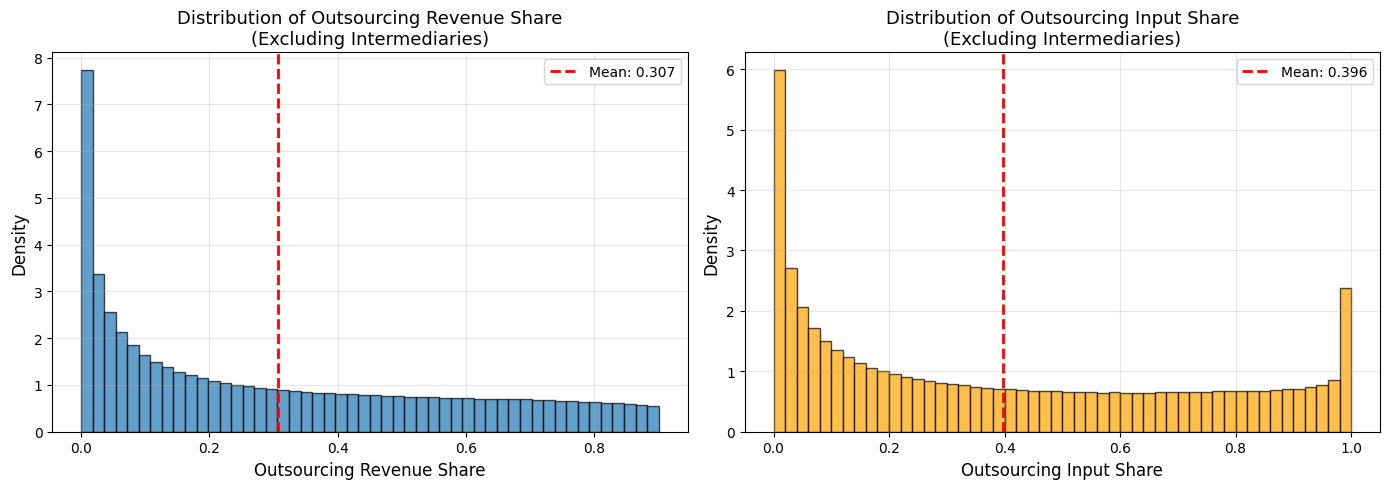

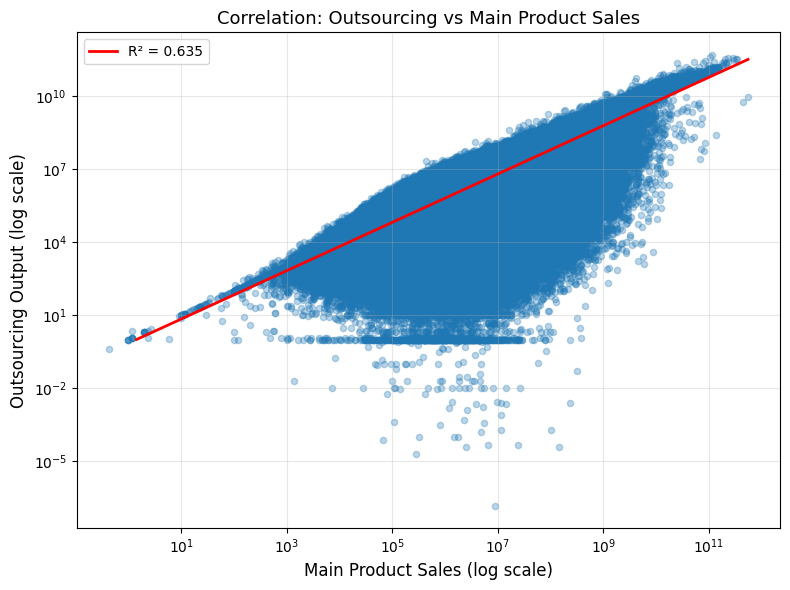

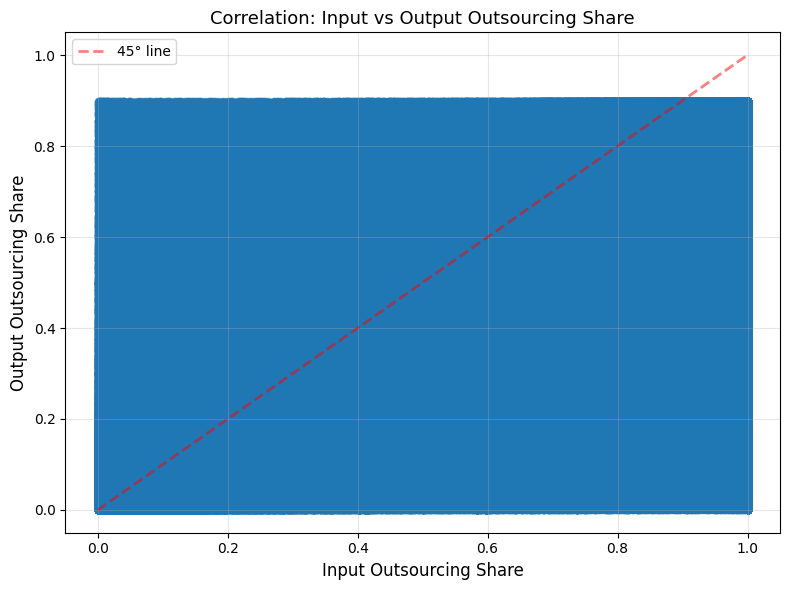

In [6]:
"""
企业外包行为描述性分析 - Part 2: 描述性统计
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
import os
warnings.filterwarnings('ignore')
os.chdir(r'G:\Kuangyu_Temp\Outsource\description')

# 读取企业汇总表
firm_agg = pd.read_stata('summary.dta')
print("读取企业汇总表完成")
print(f"数据规模: {len(firm_agg):,} 行")



# ============================================================================
# Descriptive Fact #2: 外包的普遍性和强度
# ============================================================================
print("\n" + "=" * 80)
print("Descriptive Fact #2: 外包的普遍性和强度")
print("=" * 80)

# 2.1 按年份统计有外包行为的企业占比
firm_agg['has_outsourcing'] = (firm_agg['outsourcing_intensity'] > 0).astype(int)

outsourcing_prevalence = firm_agg.groupby('year').agg({
    'firm_id': 'nunique',
    'has_outsourcing': 'sum'
}).reset_index()
outsourcing_prevalence.columns = ['year', 'total_firms', 'firms_with_outsourcing']
outsourcing_prevalence['share_with_outsourcing'] = \
    outsourcing_prevalence['firms_with_outsourcing'] / outsourcing_prevalence['total_firms']

print("\n外包企业占比（按年份）:")
print(outsourcing_prevalence.to_string(index=False))

# 保存表格
outsourcing_prevalence.to_stata('outsourcing_prevalence.dta', write_index=False)

# 2.2 外包收入份额的分布（剔除中间商）
firm_agg_no_intermediary = firm_agg[firm_agg['is_intermediary'] == 0].copy()

# 只看有外包的企业
outsourcing_firms = firm_agg_no_intermediary[firm_agg_no_intermediary['has_outsourcing'] == 1].copy()

print(f"\n外包企业数量（剔除中间商后）: {len(outsourcing_firms):,}")
print(f"外包强度统计:")
print(outsourcing_firms['outsourcing_intensity'].describe())

# 绘制外包强度的密度分布图
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 左图：外包收入份额分布
axes[0].hist(outsourcing_firms['outsourcing_intensity'], bins=50, 
             density=True, alpha=0.7, edgecolor='black')
axes[0].set_xlabel('Outsourcing Revenue Share', fontsize=12)
axes[0].set_ylabel('Density', fontsize=12)
axes[0].set_title('Distribution of Outsourcing Revenue Share\n(Excluding Intermediaries)', fontsize=13)
axes[0].grid(True, alpha=0.3)

# 添加均值线
mean_val = outsourcing_firms['outsourcing_intensity'].mean()
axes[0].axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_val:.3f}')
axes[0].legend()

# 右图：外包投入份额分布
outsourcing_firms['outsourcing_input_share'] = \
    outsourcing_firms['outsourcing_input'] / outsourcing_firms['total_input']
outsourcing_firms['outsourcing_input_share'] = \
    outsourcing_firms['outsourcing_input_share'].fillna(0)

axes[1].hist(outsourcing_firms['outsourcing_input_share'], bins=50, 
             density=True, alpha=0.7, edgecolor='black', color='orange')
axes[1].set_xlabel('Outsourcing Input Share', fontsize=12)
axes[1].set_ylabel('Density', fontsize=12)
axes[1].set_title('Distribution of Outsourcing Input Share\n(Excluding Intermediaries)', fontsize=13)
axes[1].grid(True, alpha=0.3)

# 添加均值线
mean_val2 = outsourcing_firms['outsourcing_input_share'].mean()
axes[1].axvline(mean_val2, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_val2:.3f}')
axes[1].legend()

plt.tight_layout()
plt.savefig('outsourcing_intensity_distribution.png', dpi=300, bbox_inches='tight')
print("\n外包强度分布图已保存")

# 2.3 按百分位数统计
percentiles = [10, 25, 50, 75, 90, 95, 99]
outsourcing_percentiles = outsourcing_firms['outsourcing_intensity'].quantile(
    [p/100 for p in percentiles]
).reset_index()
outsourcing_percentiles.columns = ['percentile', 'value']
outsourcing_percentiles['percentile'] = [f'P{p}' for p in percentiles]

print("\n外包强度分位数:")
print(outsourcing_percentiles.to_string(index=False))
outsourcing_percentiles.to_csv('outsourcing_intensity_percentiles.csv', index=False)

# ============================================================================
# Descriptive Fact #1: 分销不匹配（剔除中间商）
# ============================================================================
print("\n" + "=" * 80)
print("Descriptive Fact #1: 真实生产 vs 销售的分布差异")
print("=" * 80)

# 读取原始交易数据（这里需要重新加载）
# 由于原始数据太大，这部分需要在有原始数据时运行
print("\n注意：此部分需要原始交易数据，需要单独运行")

# 伪代码逻辑：
"""
# 1. 识别非中间商企业
non_intermediary_firms = firm_agg[firm_agg['is_intermediary'] == 0]['firm_id'].unique()

# 2. 筛选这些企业的交易数据
df_non_intermediary = df[df['firm_id'].isin(non_intermediary_firms)]

# 3. 区分"真实生产"和"销售"
# 真实生产 = 只卖出、不买入的产品
df_output = df_non_intermediary[df_non_intermediary['is_output'] == 1]
df_production = df_output[~df_output['is_outsourcing']]  # 非外包产品
df_sales = df_output  # 所有销售

# 4. 计算产品层面的分布
production_by_product = df_production.groupby('product_id')['v'].sum()
sales_by_product = df_sales.groupby('product_id')['v'].sum()

# 5. 计算比率
ratio_df = pd.DataFrame({
    'production': production_by_product,
    'sales': sales_by_product
}).fillna(0)
ratio_df['ratio'] = ratio_df['sales'] / (ratio_df['production'] + 1e-10)

# 6. 绘制分布图
"""

# ============================================================================
# Descriptive Fact #3: 绩效相关性分析（部分）
# ============================================================================
print("\n" + "=" * 80)
print("Descriptive Fact #3: 绩效相关性分析")
print("=" * 80)

# 3b. 外包品销售额与主营产品销售额的相关性
correlation_data = firm_agg_no_intermediary[
    (firm_agg_no_intermediary['has_outsourcing'] == 1) &
    (firm_agg_no_intermediary['main_product_sales'].notna())
].copy()

if len(correlation_data) > 0:
    corr_3b = correlation_data[['outsourcing_output', 'main_product_sales']].corr()
    print("\n3(b) 外包品销售额 vs 主营产品销售额:")
    print(corr_3b)
    
    # 绘制散点图
    fig, ax = plt.subplots(figsize=(8, 6))
    ax.scatter(correlation_data['main_product_sales'], 
               correlation_data['outsourcing_output'], 
               alpha=0.3, s=20)
    ax.set_xlabel('Main Product Sales (log scale)', fontsize=12)
    ax.set_ylabel('Outsourcing Output (log scale)', fontsize=12)
    ax.set_title('Correlation: Outsourcing vs Main Product Sales', fontsize=13)
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.grid(True, alpha=0.3)
    
    # 添加拟合线
    from scipy.stats import linregress
    log_x = np.log(correlation_data['main_product_sales'] + 1)
    log_y = np.log(correlation_data['outsourcing_output'] + 1)
    slope, intercept, r_value, p_value, std_err = linregress(log_x, log_y)
    
    x_line = np.linspace(log_x.min(), log_x.max(), 100)
    y_line = slope * x_line + intercept
    ax.plot(np.exp(x_line), np.exp(y_line), 'r-', linewidth=2, 
            label=f'R² = {r_value**2:.3f}')
    ax.legend()
    
    plt.tight_layout()
    plt.savefig('correlation_outsourcing_main_product.png', 
                dpi=300, bbox_inches='tight')
    print("相关性图已保存")

# 3d. 投入品外包份额与产出品外包份额的相关性
correlation_data_3d = firm_agg_no_intermediary[
    (firm_agg_no_intermediary['has_outsourcing'] == 1) &
    (firm_agg_no_intermediary['total_input'] > 0)
].copy()

if len(correlation_data_3d) > 0:
    corr_3d = correlation_data_3d[['outsourcing_intensity', 'outsourcing_input_share']].corr()
    print("\n3(d) 产出品外包份额 vs 投入品外包份额:")
    print(corr_3d)
    
    # 绘制散点图
    fig, ax = plt.subplots(figsize=(8, 6))
    ax.scatter(correlation_data_3d['outsourcing_input_share'], 
               correlation_data_3d['outsourcing_intensity'], 
               alpha=0.3, s=20)
    ax.set_xlabel('Input Outsourcing Share', fontsize=12)
    ax.set_ylabel('Output Outsourcing Share', fontsize=12)
    ax.set_title('Correlation: Input vs Output Outsourcing Share', fontsize=13)
    ax.grid(True, alpha=0.3)
    
    # 添加45度线
    max_val = max(correlation_data_3d['outsourcing_input_share'].max(),
                  correlation_data_3d['outsourcing_intensity'].max())
    ax.plot([0, max_val], [0, max_val], 'r--', linewidth=2, alpha=0.5, label='45° line')
    ax.legend()
    
    plt.tight_layout()
    plt.savefig('correlation_input_output_outsourcing.png', 
                dpi=300, bbox_inches='tight')
    print("相关性图已保存")

# ============================================================================
# 汇总统计表
# ============================================================================
print("\n" + "=" * 80)
print("生成汇总统计表")
print("=" * 80)

summary_stats = pd.DataFrame({
    'Variable': [
        'Total Output',
        'Total Input', 
        'Outsourcing Output',
        'Outsourcing Input',
        'Outsourcing Intensity',
        'Number of Products',
        'Number of Outsourcing Products'
    ],
    'Mean': [
        firm_agg_no_intermediary['total_output'].mean(),
        firm_agg_no_intermediary['total_input'].mean(),
        firm_agg_no_intermediary['outsourcing_output'].mean(),
        firm_agg_no_intermediary['outsourcing_input'].mean(),
        firm_agg_no_intermediary['outsourcing_intensity'].mean(),
        firm_agg_no_intermediary['n_products'].mean(),
        firm_agg_no_intermediary['n_outsourcing_products'].mean()
    ],
    'Std': [
        firm_agg_no_intermediary['total_output'].std(),
        firm_agg_no_intermediary['total_input'].std(),
        firm_agg_no_intermediary['outsourcing_output'].std(),
        firm_agg_no_intermediary['outsourcing_input'].std(),
        firm_agg_no_intermediary['outsourcing_intensity'].std(),
        firm_agg_no_intermediary['n_products'].std(),
        firm_agg_no_intermediary['n_outsourcing_products'].std()
    ],
    'Min': [
        firm_agg_no_intermediary['total_output'].min(),
        firm_agg_no_intermediary['total_input'].min(),
        firm_agg_no_intermediary['outsourcing_output'].min(),
        firm_agg_no_intermediary['outsourcing_input'].min(),
        firm_agg_no_intermediary['outsourcing_intensity'].min(),
        firm_agg_no_intermediary['n_products'].min(),
        firm_agg_no_intermediary['n_outsourcing_products'].min()
    ],
    'Max': [
        firm_agg_no_intermediary['total_output'].max(),
        firm_agg_no_intermediary['total_input'].max(),
        firm_agg_no_intermediary['outsourcing_output'].max(),
        firm_agg_no_intermediary['outsourcing_input'].max(),
        firm_agg_no_intermediary['outsourcing_intensity'].max(),
        firm_agg_no_intermediary['n_products'].max(),
        firm_agg_no_intermediary['n_outsourcing_products'].max()
    ]
})

print("\n描述性统计（剔除中间商）:")
print(summary_stats.to_string(index=False))

summary_stats.to_stata('summary_statistics.dta', write_index=False)

print("\n" + "=" * 80)
print("所有分析完成！")
print("=" * 80)
